# 04 — FSRQ Gamma-Ray Luminosity Function

Flat-Spectrum Radio Quasars are luminous blazars with strong emission lines.
Their LDDE (Ajello+ 2012) has a much steeper positive evolution ($p_1=7.35$)
than BL Lacs ($p_1=4.50$), a softer spectrum ($\alpha=2.44$), and a higher
minimum luminosity ($L_\mathrm{min}=10^{44}$ erg/s), making them more heavily resolved.

**References:** `docs/equations.md` §5; Ajello+ (2012) Table 3.

In [1]:
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'hi_gamma_xcorr').is_dir():
            return candidate
    raise RuntimeError(f'Could not locate repo root from {start}')

REPO_ROOT = _find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import matplotlib.pyplot as plt
from hi_gamma_xcorr import config as cfg, cosmology as cosmo
from hi_gamma_xcorr import plotting as sty
cosmo.init()
print("Pipeline initialized.")

Pipeline initialized.


In [2]:
from hi_gamma_xcorr import astro_sources as astro

## 1. GLF Comparison: FSRQ vs BL Lac

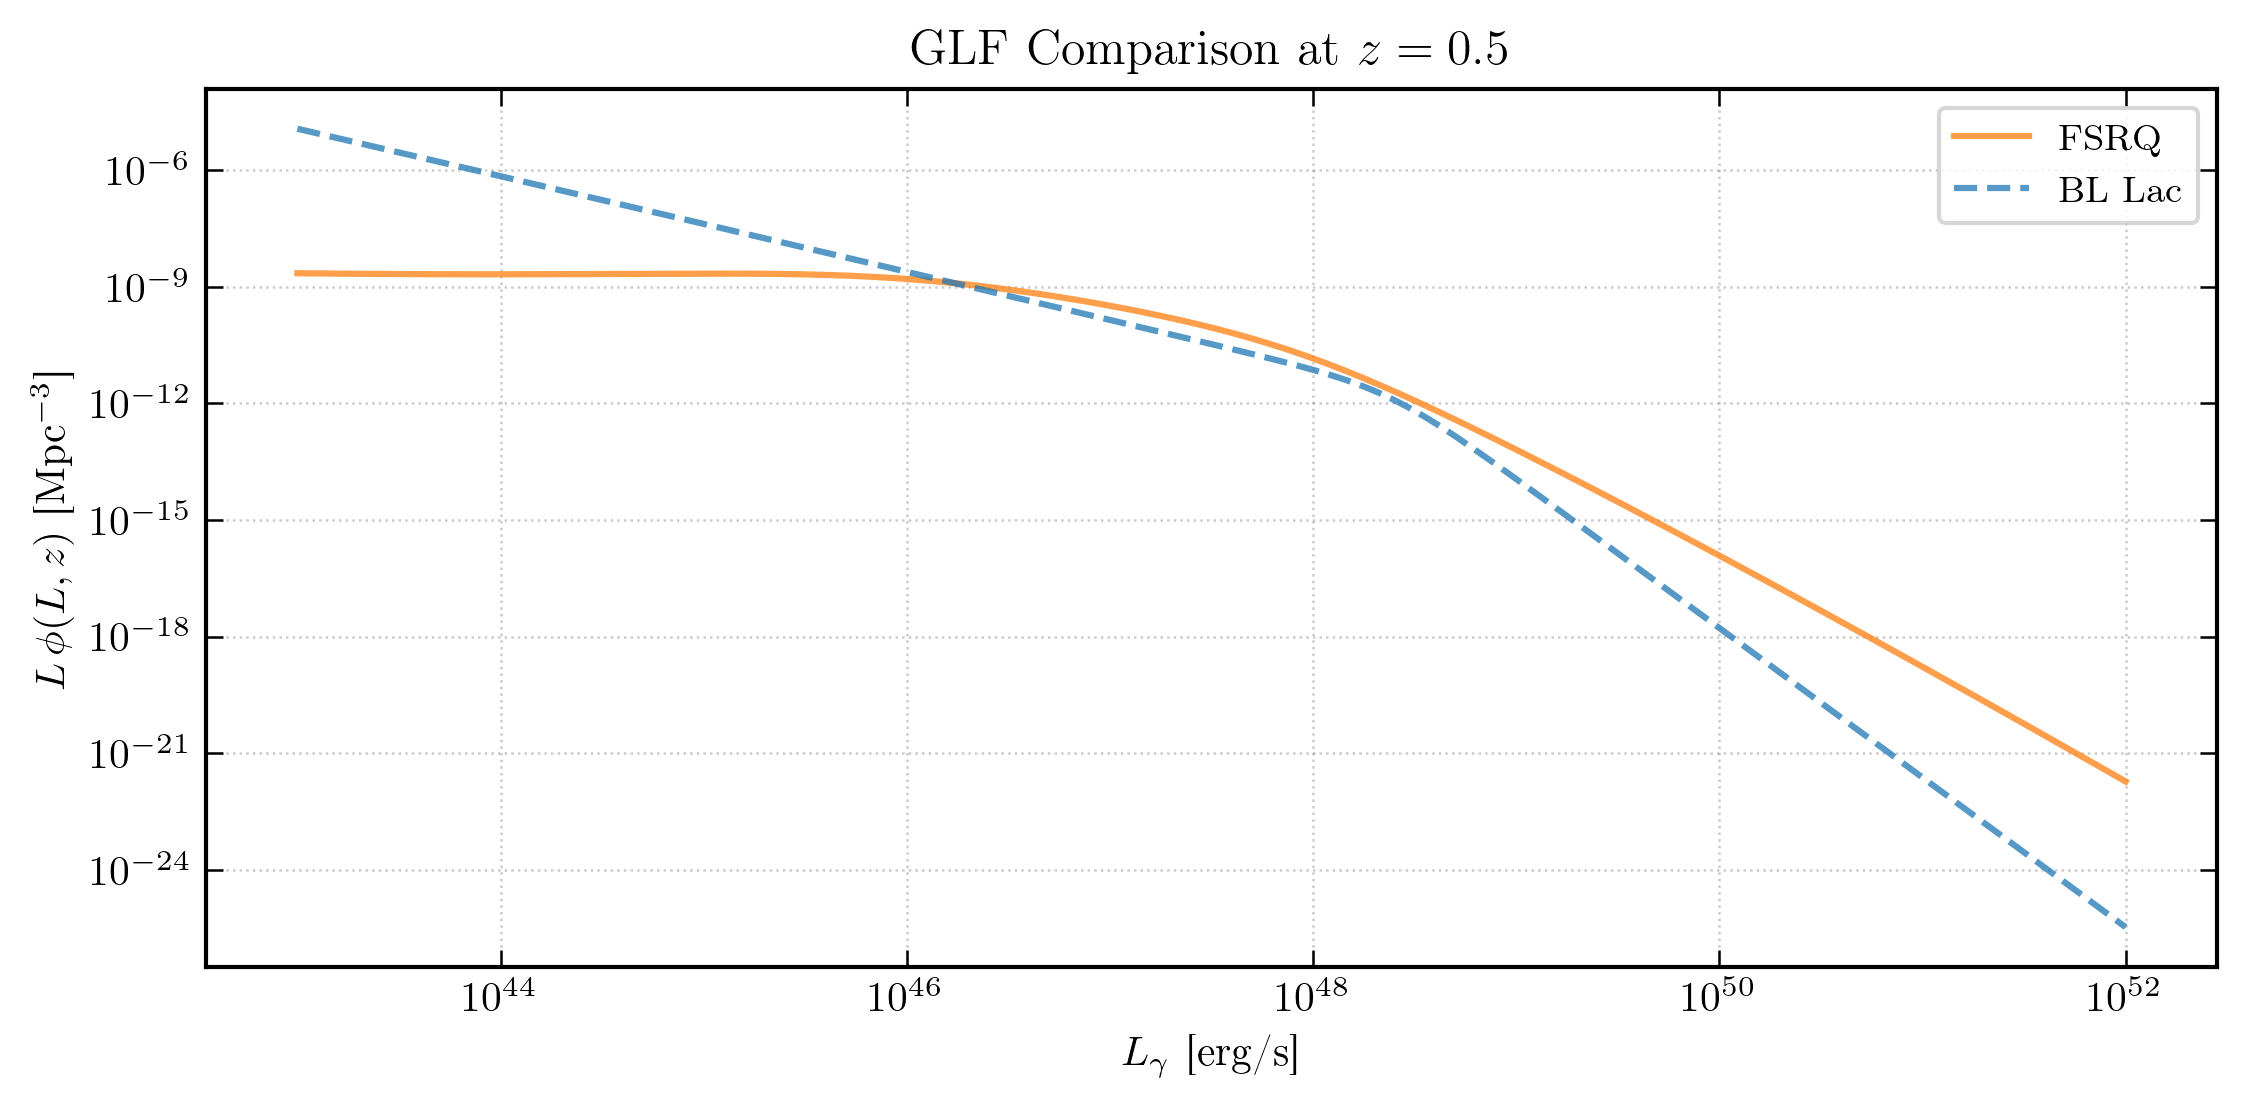

In [3]:
L_arr = np.logspace(43, 52, 200)
fig, ax = sty.textwidth_figure(8)
z_ref = 0.5
phi_fsrq = np.array([astro.glf(L, z_ref, 'FSRQ') for L in L_arr])
phi_bl = np.array([astro.glf(L, z_ref, 'BL_Lac') for L in L_arr])
ax.loglog(L_arr, L_arr * phi_fsrq, 'C1', **sty.FIT_STYLE, label='FSRQ')
ax.loglog(L_arr, L_arr * phi_bl, 'C0', **sty.MODEL_STYLE, label='BL Lac')
ax.set_xlabel(r'$L_\gamma$ [erg/s]'); ax.set_ylabel(r'$L\,\phi(L,z)$ [Mpc$^{-3}$]')
ax.set_title(f'GLF Comparison at $z = {z_ref}$'); ax.legend(); fig.tight_layout()

## 2. FSRQ GLF at Multiple Redshifts

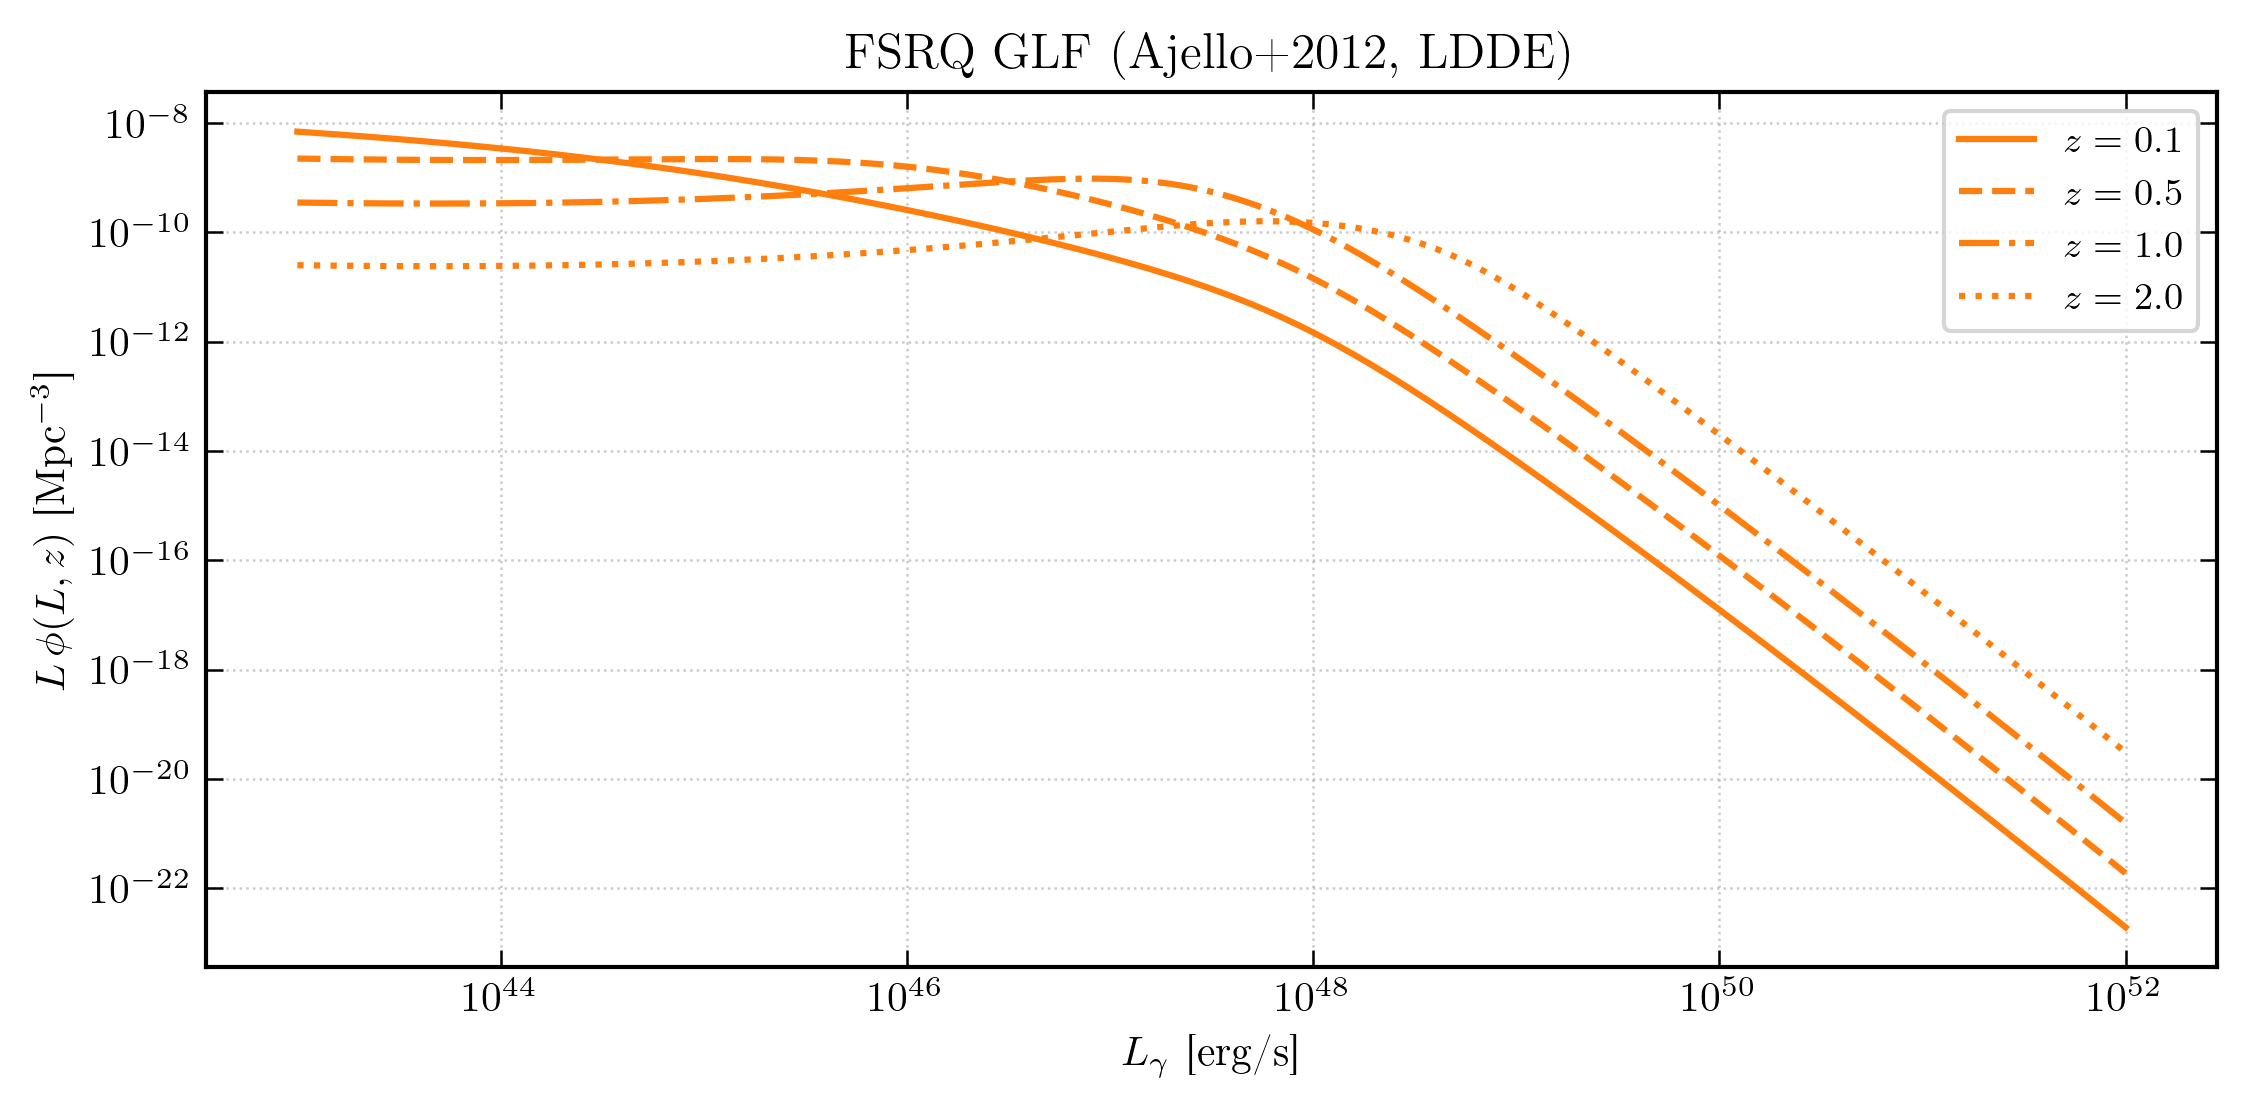

In [4]:
fig, ax = sty.textwidth_figure(8)
for z, ls in [(0.1, '-'), (0.5, '--'), (1.0, '-.'), (2.0, ':')]:
    phi = np.array([astro.glf(L, z, 'FSRQ') for L in L_arr])
    ax.loglog(L_arr, L_arr * phi, ls=ls, color='C1', lw=sty.LW_STANDARD, label=f'$z={z}$')
ax.set_xlabel(r'$L_\gamma$ [erg/s]'); ax.set_ylabel(r'$L\,\phi(L,z)$ [Mpc$^{-3}$]')
ax.set_title('FSRQ GLF (Ajello+2012, LDDE)'); ax.legend(); fig.tight_layout()

## 3. Window Function and Mean Intensity

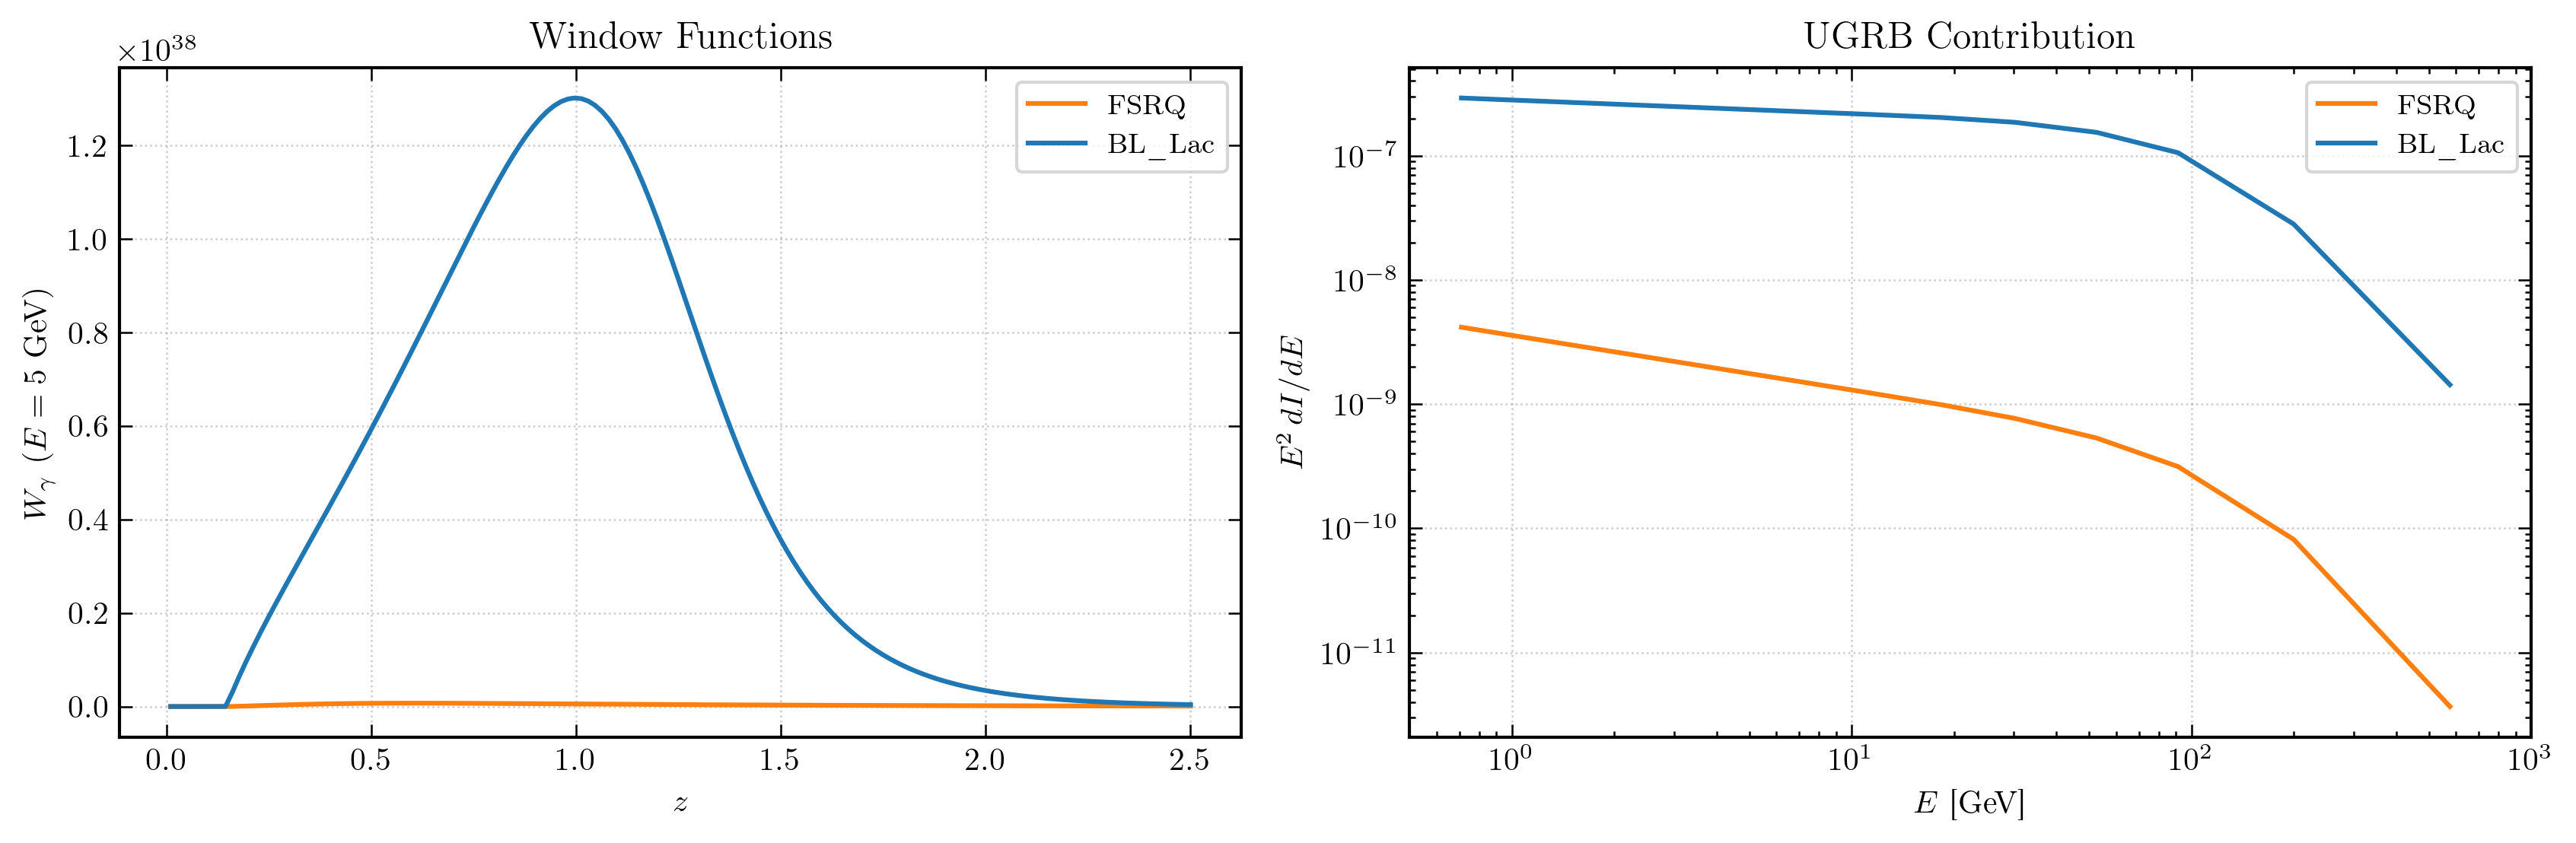

In [5]:
z_w = np.linspace(0.01, 2.5, 150)
E_arr = cfg.FERMI_E_B

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(sty.TEXTWIDTH_IN * 1.5, sty.TEXTWIDTH_IN * 0.5))
# Window
for src, color in [('FSRQ', 'C1'), ('BL_Lac', 'C0')]:
    W = np.array([astro.W_gamma_astro(5.0, z, src) for z in z_w])
    ax1.plot(z_w, W, color=color, lw=sty.LW_STANDARD, label=src)
ax1.set_xlabel('$z$'); ax1.set_ylabel(r'$W_\gamma$ ($E=5$ GeV)')
ax1.set_title('Window Functions'); ax1.legend()

# Intensity
for src, color in [('FSRQ', 'C1'), ('BL_Lac', 'C0')]:
    I = np.array([astro.mean_intensity(E, src) for E in E_arr])
    ax2.loglog(E_arr, E_arr**2 * I, color=color, lw=sty.LW_STANDARD, label=src)
ax2.set_xlabel('$E$ [GeV]'); ax2.set_ylabel(r'$E^2\,dI/dE$')
ax2.set_title('UGRB Contribution'); ax2.set_xlim(0.5, 1000); ax2.legend()
fig.tight_layout()

## 4. LDDE Parameter Comparison

| Parameter | BL Lac | FSRQ |
|-----------|--------|------|
| $A$ [Mpc$^{-3}$] | $9.20\times10^{-11}$ | $3.06\times10^{-9}$ |
| $L_c$ [erg/s] | $2.43\times10^{48}$ | $8.4\times10^{47}$ |
| $\gamma_1$ | 1.12 | 0.21 |
| $\gamma_2$ | 3.71 | 1.58 |
| $z_c^*$ | 1.67 | 1.47 |
| $p_1$ | 4.50 | 7.35 |
| $p_2$ | $-12.88$ | $-6.51$ |
| $\alpha$ (spectral) | 2.11 | 2.44 |